<a href="https://colab.research.google.com/github/Priyankaraman-0577/DWDM-UNIT_5/blob/main/Copy_of_Untitled9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install numpy

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score


In [ ]:
df = pd.read_csv("/content/ecommerce_data_large.csv")


In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)
df.drop_duplicates(inplace=True)


In [ ]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month

In [ ]:
df.rename(columns={'Total_Amount': 'Sales'}, inplace=True)


In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop(['Sales'], axis=1)
y = df['Sales']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LinearRegression()
X_train_cleaned = X_train.drop(columns=['Order_Date', 'Order_ID'], errors='ignore')
model.fit(X_train_cleaned, y_train)

LinearRegression()

In [ ]:
X_test_cleaned = X_test.drop(columns=['Order_Date', 'Order_ID'], errors='ignore')
y_pred = model.predict(X_test_cleaned)

In [ ]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))


MAE: 33245.71331759658
R2: 0.7708613482676526


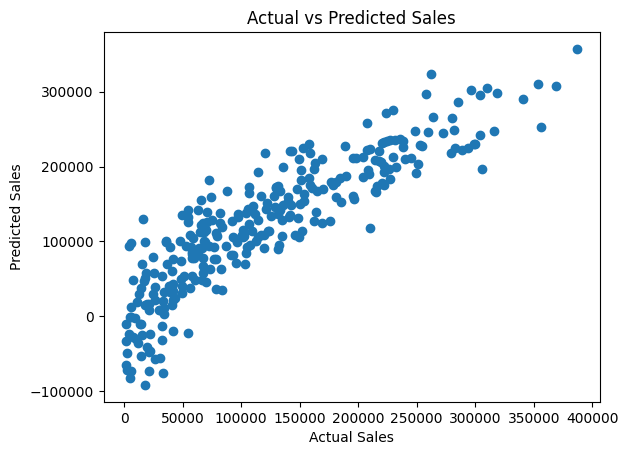

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()


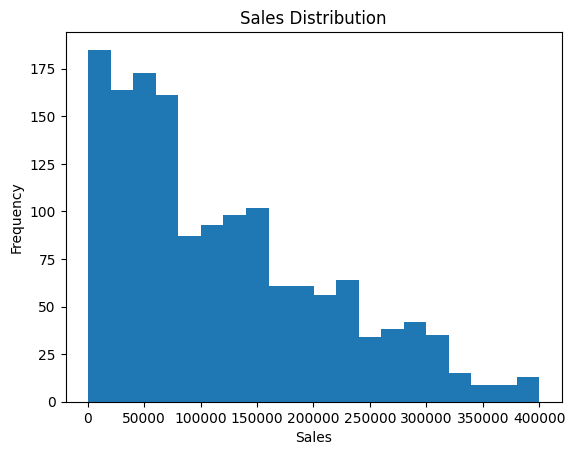

In [ ]:
plt.figure()
plt.hist(df['Sales'], bins=20)
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Sales Distribution")
plt.show()


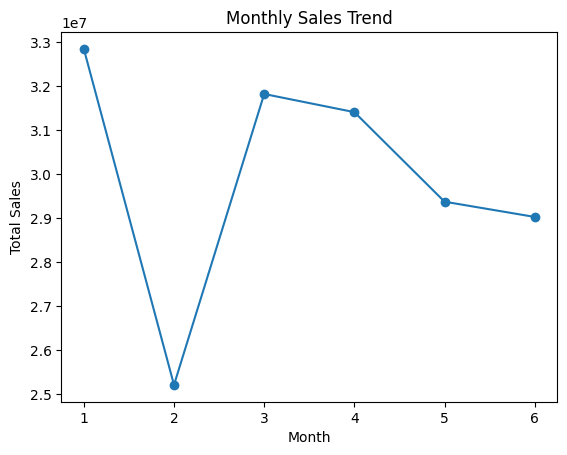

In [ ]:
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure()
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend")
plt.show()


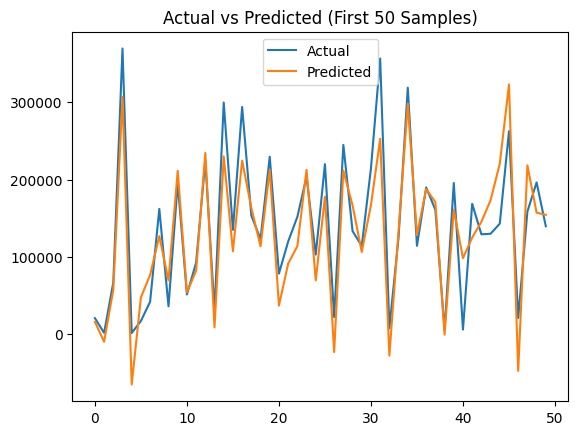

In [ ]:
plt.figure()
plt.plot(y_test.values[:50], label="Actual")
plt.plot(y_pred[:50], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted (First 50 Samples)")
plt.show()